# Random Forest Classifier using Scikit-learn

Random Forest is a method that combines the predictions of multiple decision trees to produce a more accurate and stable result. It can be used for both classification and regression tasks. In classification tasks, Random Forest Classification predicts categorical outcomes based on the input data. It uses multiple decision trees and outputs the label that has the maximum votes among all the individual tree predictions.

## Working of Random Forest Classifier
1. **Bootstrap Sampling**: Random rows are picked (with replacement) to train each tree.
2. **Random Forest Selection**: Each tree uses a random set of features (not all features).
3. **Build Decision Trees.**: Trees split the data using the best features from their random set. Splitting contines until a stopping rule is met (like max depth).
4. **Make Predictions**: Each tree gives its own preditions.
5. **Majority Voting**: The final prediction is the one most tree agree on.

## Benefits of Random Forest Classification
* Random Forest can handle large datasets and high-dimensional data.
* By combining predictions from many decision trees, it reduces the risk of overfitting compared to a single decision tree.
* It is robust to noisy data and works well with categorical data.

## Implementing Random Forest Classification in Python
Before implementing random forest classifier in Python let's first understand its parameters. 
* **n_estimators**: Number of trees in the forest.
* **max_depth**: Maximum depth of each tree.
* **max_features**: Number of features considered for splitting at each node.
* **criterion**: Function used to measure split quality ('gini' or 'entropy')
* **min_samples_split**: Minimum samples required to split a node.
* **min_samples_lead**: Minimum samples required to be a leaf node.
* **bootstrap**: Whether to use bootstrap sampling when building trees (True or False)

# Implementing Random Forest Classification

## 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

## 2. Import Dataset

In [11]:
df = pd.read_csv("training_features.csv")

In [12]:
df.head()

,StartTime,EndTime,DurationHours,FlowMode,is_ramadan,is_public_holiday,label,day_type_weekday,day_type_weekend,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,time_of_day_night,time_of_day_other,rms,peak_flow_rate,volume,average_flow_rate,std_dev,variance,mode_flow_rate,ir1,ir2,cx
0,2026-01-28 02:53:30,2026-01-28 02:54:30,0.016667,403.50,0,0,toilet_flush,1,0,0,0,0,1,0,408.310002,419.40,6.850417,408.233333,9.690471,93.905233,402.46425,-5.845752,16.93575,0.666667
1,2026-01-28 02:55:00,2026-01-28 02:56:00,0.016667,736.00,0,0,bidet,1,0,0,0,0,1,0,749.346381,782.14,12.398542,748.973333,28.955421,838.416433,730.06525,-19.281131,52.07475,0.666667
2,2026-01-28 02:56:30,2026-01-28 02:57:00,0.008333,300.50,0,0,faucet,1,0,0,0,0,1,0,300.724574,305.25,2.505750,300.690000,6.448814,41.587200,296.35800,-4.366574,8.89200,0.500000
3,2026-01-28 06:35:00,2026-01-28 06:39:30,0.075000,318.32,0,0,toilet_flush,1,0,0,0,1,0,0,317.103750,318.32,23.822417,317.082000,3.914900,15.326440,318.01050,0.906750,0.30950,0.100000
4,2026-01-28 06:36:30,2026-01-28 06:38:00,0.025000,79.50,0,0,bidet,1,0,0,0,1,0,0,79.500000,79.50,1.987500,79.500000,0.000000,0.000000,79.50000,0.000000,0.00000,0.000000


## 3. Data Preparation

In [23]:
column_name = "label"
df[column_name] = df.pop(column_name)
df.iloc[:, 2:-4].head()

,DurationHours,FlowMode,is_ramadan,is_public_holiday,day_type_weekday,day_type_weekend,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,time_of_day_night,time_of_day_other,rms,peak_flow_rate,volume,average_flow_rate,std_dev,variance,mode_flow_rate
0,0.016667,403.50,0,0,1,0,0,0,0,1,0,408.310002,419.40,6.850417,408.233333,9.690471,93.905233,402.46425
1,0.016667,736.00,0,0,1,0,0,0,0,1,0,749.346381,782.14,12.398542,748.973333,28.955421,838.416433,730.06525
2,0.008333,300.50,0,0,1,0,0,0,0,1,0,300.724574,305.25,2.505750,300.690000,6.448814,41.587200,296.35800
3,0.075000,318.32,0,0,1,0,0,0,1,0,0,317.103750,318.32,23.822417,317.082000,3.914900,15.326440,318.01050
4,0.025000,79.50,0,0,1,0,0,0,1,0,0,79.500000,79.50,1.987500,79.500000,0.000000,0.000000,79.50000


In [32]:
print(df.iloc[1:3, 2:-4].values)
print(f"Shape: {(df.iloc[1:3, 2:-4].values).shape}")

[[1.66666667e-02 7.36000000e+02 0.00000000e+00 0.00000000e+00
  1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.00000000e+00 0.00000000e+00 7.49346381e+02
  7.82140000e+02 1.23985417e+01 7.48973333e+02 2.89554215e+01
  8.38416433e+02 7.30065250e+02]
 [8.33333333e-03 3.00500000e+02 0.00000000e+00 0.00000000e+00
  1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.00000000e+00 0.00000000e+00 3.00724574e+02
  3.05250000e+02 2.50575000e+00 3.00690000e+02 6.44881384e+00
  4.15872000e+01 2.96358000e+02]]
Shape: (2, 18)


In [24]:
X = df.iloc[:,2:-4].values
y = df.iloc[:, -1].values

In [40]:
print(f"Training Set : \n{X} \nShape: {X.shape}")

Training Set : 
[[1.66666667e-02 4.03500000e+02 0.00000000e+00 ... 9.69047126e+00
  9.39052333e+01 4.02464250e+02]
 [1.66666667e-02 7.36000000e+02 0.00000000e+00 ... 2.89554215e+01
  8.38416433e+02 7.30065250e+02]
 [8.33333333e-03 3.00500000e+02 0.00000000e+00 ... 6.44881384e+00
  4.15872000e+01 2.96358000e+02]
 ...
 [0.00000000e+00 6.75000000e+02 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 6.75050000e+02]
 [1.50000000e-01 5.17790000e+02 0.00000000e+00 ... 1.36174625e+01
  1.85435284e+02 5.17651500e+02]
 [8.33333333e-03 8.59500000e+02 0.00000000e+00 ... 2.74145299e+01
  7.51556450e+02 8.41159250e+02]] 
Shape: (126291, 18)


In [35]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y)
y_encoded = le.transform(y)

LabelEncoder()

In [39]:
print(f"Lables: {y} \nEncoded Labels: {y_encoded} \nShape: {y_encoded.shape}")

Lables: ['toilet_flush' 'bidet' 'faucet' ... 'washing_machine' 'shower' 'bidet'] 
Encoded Labels: [4 0 2 ... 5 3 0] 
Shape: (126291,)


## 4. Splitting the Dataset

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [42]:
print(f"Shape of Training Set: {X_train.shape}, Training Label: {y_train.shape}")
print(f"Shape of Testing Set: {X_test.shape}, Testing Label : {y_test.shape}")

Shape of Training Set: (101032, 18), Training Label: (101032,)
Shape of Testing Set: (25259, 18), Testing Label : (25259,)


## 5. Feature Scaling

In [43]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [46]:
print(X_train[1])

[-0.26411537  0.65939432 -0.10311788 -0.05195656  0.62981398 -0.62981398
 -0.54755341 -0.46372677  1.29047667 -0.35458401 -0.34339449  0.6942195
  0.75140584 -0.14737739  0.69346516  1.40975337  0.93168514  0.65656918]


## 6. Building Random Foreset Classifier
We will create the Random Forest Classifier model, train it on the training data and make predictions on the test data. 
* **RandomForestClassifier(n_estimator=100, random_state=42)** creates 100 trees
* **classifier.fit(X_train, y_train)** trains on training data.
* **classifier.predict(X_test)** predicts on test data.
* **random_forest=42** ensures reproducible results.

In [47]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

## 7. Evaluation of the Model

In [49]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 79.98%


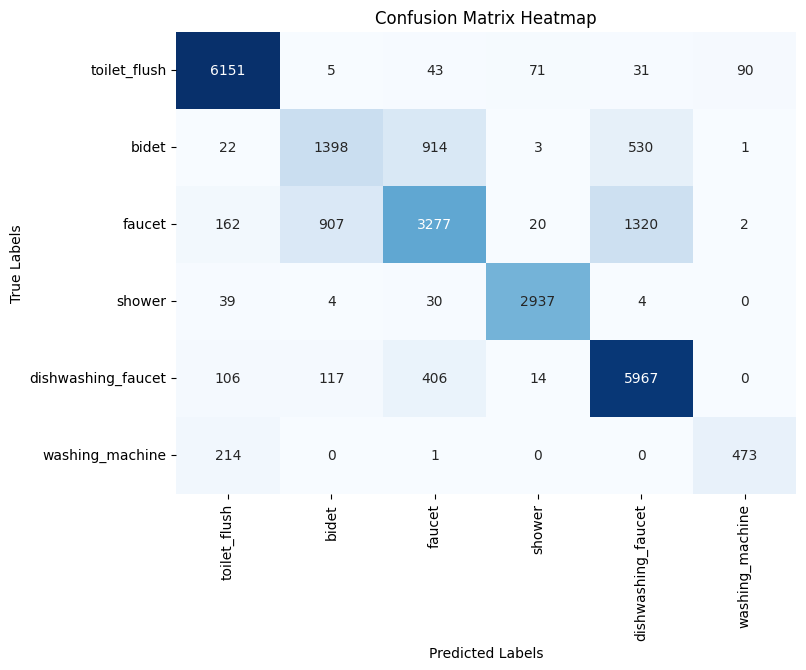

In [60]:
conf_matrix = confusion_matrix(y_test, y_pred)
unique_labels = df['label'].unique()

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=unique_labels, yticklabels=unique_labels)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## 8. Feature Importance
Random Forest Classifiers also provide insight into which features were the most important in making predictions. We can plot the feature importance.

In [61]:
feature_df = df.iloc[:,2:-4]

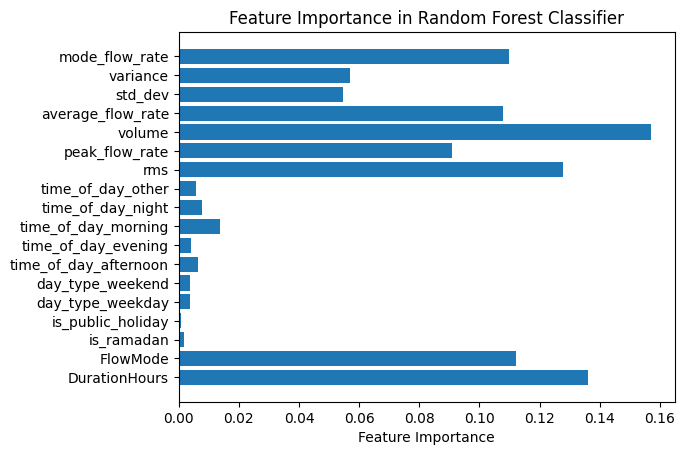

In [62]:
feature_importance = classifier.feature_importances_
features = feature_df.columns

plt.barh(features, feature_importance)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()